# Problem: gravity

**Simulations** — the ones from a first-year mechanics course, run here so the
law can be recovered from data whose answer is known exactly.

**Real data** — Kepler's third law from the JPL DE441 ephemeris, eight planets.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## 1 · The integrator is part of the physics model

Velocity Verlet is symplectic: its energy error oscillates and stays bounded.
RK4 has better local accuracy and is not symplectic: its error *drifts*, and a
bound orbit slowly spirals. Mercury is used because `e = 0.206` makes
perihelion the hard part.

,dt_days,steps_per_orbit,verlet_energy_drift,verlet_energy_spread,rk4_energy_drift
0,0.25,351.878830,0.000081,0.000087,8.398281e-07
1,1.00,87.969707,0.000857,0.001396,8.603008e-04
2,2.00,43.984854,0.000387,0.005670,2.890584e-02
3,4.00,21.992427,0.011251,0.024036,1.650931e+01


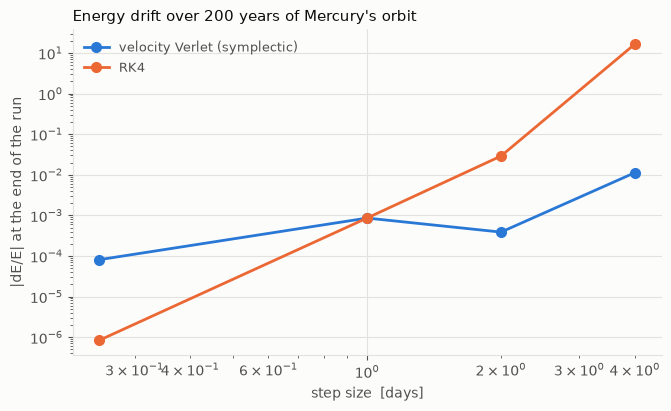

In [2]:
ic = load_table("gravity", "integrator_comparison")
display(ic[["dt_days","steps_per_orbit","verlet_energy_drift",
            "verlet_energy_spread","rk4_energy_drift"]])
fig, ax = plt.subplots(figsize=(6.6,4.0))
ax.loglog(ic.dt_days, ic.verlet_energy_drift, "o-", color=P.ARM_COLOR["physics"],
          label="velocity Verlet (symplectic)")
ax.loglog(ic.dt_days, ic.rk4_energy_drift, "o-", color=P.ARM_COLOR["sr"], label="RK4")
P._style(ax, "Energy drift over 200 years of Mercury's orbit",
         "step size  [days]", "|dE/E| at the end of the run")
ax.legend(fontsize=9, labelcolor=P.INK_2); plt.show()

## 2 · Watch them run

In [3]:
display(gif("gravity/two_body_mercury.gif", 460,
            "Sun + Mercury, velocity Verlet. The Sun moves too: this is the "
            "centre-of-mass frame."))

### The three-body problem

Left: the Chenciner–Montgomery **figure-eight choreography** — a genuinely
periodic solution in which all three bodies chase each other around the *same*
curve. Right: the same initial conditions, perturbed.

In [4]:
display(gif("gravity/three_body_figure8.gif", 420, "the periodic choreography"))
display(gif("gravity/three_body_chaotic.gif", 420, "perturbed by 1e-3"))

**Chaos is a measurement, not an adjective.** Two figure-eights whose initial
conditions differ by one part in 10⁹ are integrated side by side and their
separation is tracked.

In [5]:
m = load_json("gravity", "problem_meta")
ly = m["simulations"]["lyapunov"]
print(f"Lyapunov exponent  lambda = {ly['lambda']:.4f} per time unit")
print(f"e-folding time            = {ly['e_folding_periods']:.2f} periods")
display(gif("gravity/lyapunov.png", 560))

Lyapunov exponent  lambda = 0.0387 per time unit
e-folding time            = 4.09 periods


### And the real solar system, from real JPL initial conditions

In [6]:
display(gif("gravity/solar_system_inner.gif", 460,
            "Only the state at the epoch comes from the ephemeris; "
            "everything after is this integrator's own Newtonian solution."))
print("energy drift over the run:", m["simulations"]["solar_system_drift"])

energy drift over the run: {'L_rel_drift': 3.162354432566238e-16, 'energy_rel_drift': 5.812478404734327e-07, 'energy_rel_spread': 1.0374419142642104e-05}


## 3 · Recover the law of gravity from the simulation

Symbolic regression is given nothing but the orbit's radius and the magnitude
of its acceleration. The exponent it returns should be −2, exactly.

In [7]:
fl = m["discovery"]["force_law"]
print("SR expression      :", fl["sr_expression"])
print(f"exponent, SR       : {fl['exponent_sr']:.7f}   (true -2)")
print(f"exponent, log-log  : {fl['exponent_loglog']:.7f}")
print(f"GM, direct fit     : {fl['mu_direct_rel_error_ppb']:+.1f} ppb")
print(f"GM, log-log interc.: {fl['mu_loglog_rel_error_ppm']:+.1f} ppm  <- biased estimator")
print(f"radius range       : x{fl['r_dynamic_range']:.2f}  (a circular orbit could not do this)")

SR expression      : (1.6283178e-6 + 0.93858665/r)/r
exponent, SR       : -1.9999983   (true -2)
exponent, log-log  : -1.9999987
GM, direct fit     : -324.4 ppb
GM, log-log interc.: -32.5 ppm  <- biased estimator
radius range       : x1.52  (a circular orbit could not do this)


### Kepler's third law, from simulated orbits

Each planet is simulated and its period **measured from the trajectory** —
successive perihelion passages — not read from the table that went in.

In [8]:
kl = m["discovery"]["kepler_law"]
display(load_table("gravity","kepler_from_simulation"))
print("SR:", kl["sr_expression"])
print(f"exponent: SR {kl['exponent_sr']:.6f} | log-log {kl['exponent_loglog']:.6f}  (true 1.5)")

,planet,a_au,ecc,period_sim_d,period_kepler_d,period_rel_err
0,Mercury,0.38710,0.20563,87.969861,87.969707,1.748314e-06
1,Venus,0.72333,0.00677,224.699849,224.699762,3.882606e-07
2,Earth,1.00000,0.01671,365.256504,365.256350,4.233026e-07
3,Mars,1.52371,0.09339,686.992778,686.992243,7.780130e-07
4,Jupiter,5.20288,0.04839,4332.685683,4332.683300,5.499378e-07
5,Saturn,9.53667,0.05386,10755.528394,10755.522217,5.743755e-07
6,Uranus,19.18916,0.04726,30702.456825,30702.440092,5.449903e-07
7,Neptune,30.06992,0.00859,60226.250113,60226.226352,3.945257e-07


SR: (0.6686826*sqrt(a) + 0.0007770811)*(a - 0.0012930512) + 0.00019282666
exponent: SR 1.498586 | log-log 1.499974  (true 1.5)


### The same law, recovered from the *chaotic* run

The trajectory is unpredictable beyond a few periods. The law behind it is
not. **Chaos is a property of the solution, not of the equation** — and
symbolic regression only ever sees the equation.

In [9]:
cl = m["discovery"]["chaotic_law"]
print(f"G*m recovered : {cl['Gm_recovered']:.9f}  (true 1)  -> {cl['Gm_rel_error_ppm']:+.3f} ppm")
print(f"fit residual  : {cl['residual_rel']:.2e}   over {cl['n_samples']:,} samples")
print(f"Lyapunov      : {cl['lyapunov']:.4f}  (the trajectory really is chaotic)")

G*m recovered : 0.999999187  (true 1)  -> -0.813 ppm
fit residual  : 1.08e-06   over 35,995 samples
Lyapunov      : 0.0462  (the trajectory really is chaotic)


## 4 · Watch a PINN learn

The network is fitted to a noisy radius-versus-time series from the simulated
orbit, with `GM` a trainable constant started at 55% of its true value. The
right-hand panel is the point.

In [10]:
tr = m["training"]
display(gif("gravity/pinn_learning_orbit.gif", 820))
print(f"GM started at {tr['GM_initial']:.4e}")
print(f"GM ended at   {tr['GM_recovered']:.4e}   (true {tr['GM_true']:.4e})")
print(f"final error   {tr['GM_rel_error_ppm']:+.0f} ppm, from data with "
      f"{tr['noise_frac']*100:.0f}% noise")

GM started at 7.2992e+19
GM ended at   1.3219e+20   (true 1.3271e+20)
final error   -3930 ppm, from data with 2% noise


## 5 · The real data: Kepler's third law from JPL DE441

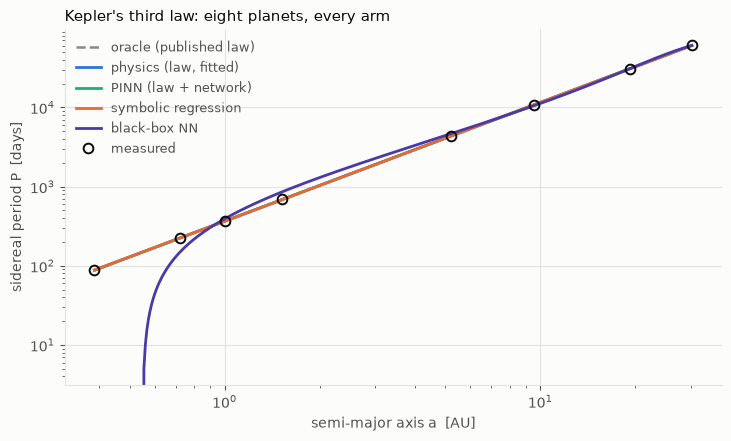

GM_sun fitted = 1.327203e+20 +- 3.4e+15
IAU nominal   = 1.327124e+20  (+59.3 ppm)
SR: {'deviation': -0.0013945223753693003, 'exponent': 1.4986054776246307, 'expression': '(0.3651406*sqrt(a) + 0.00123135648862424)*(a - 0.010904807) + 0.0025760839', 'kepler_exponent': 1.5}


In [11]:
from physprior.problems.gravity import kepler
prob, meta = kepler.problem()
meta = {**meta, **load_json("gravity/kepler", "meta")}
fits = {a: fit_arm(a, prob, np.arange(len(prob)), seed=11)
        for a in ["oracle","physics","pinn","sr","nn"]}
P.fig_overview(prob, fits, logx=True, logy=True,
               title="Kepler's third law: eight planets, every arm"); plt.show()
f = fits["physics"]
print(f"GM_sun fitted = {f.params['GM']:.6e} +- {f.param_sigma['GM']:.1e}")
print(f"IAU nominal   = {meta['published_GM_sun']:.6e}  "
      f"({(f.params['GM']-meta['published_GM_sun'])/meta['published_GM_sun']*1e6:+.1f} ppm)")
print("SR:", meta["headline"]["sr"]["law_check"])

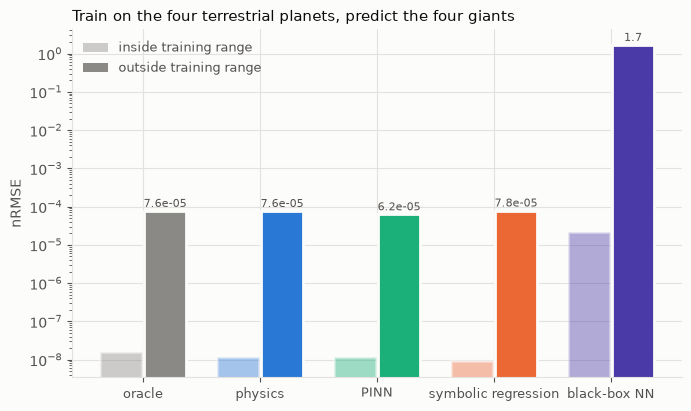

,nrmse_in,nrmse_out
arm,,
nn,2.123769e-05,1.660475
oracle,1.537401e-08,0.000076
physics,1.144904e-08,0.000076
pinn,1.163204e-08,0.000062
sr,8.926247e-09,0.000078


In [12]:
ex = load_table("gravity/kepler","extrapolation")
P.fig_extrapolation_bars(ex, "Train on the four terrestrial planets, predict the four giants")
plt.show()
ex.groupby("arm")[["nrmse_in","nrmse_out"]].median()

**Verdict.** The simulation says the method can recover the exponent to 3×10⁻⁶
and `GM` to sub-ppb when the law is exactly right. The ephemeris then returns
`GM_sun` to tens of ppm — and that residual is *physics*, not method: the
two-body formula `P = 2π√(a³/GM)` neglects the planets' own masses and uses
the osculating rather than the mean semi-major axis.

---

## Conclusion

Everything below is rendered from `results/` at execution time by
`physprior.reporting.conclusions` — the verdicts, the margins and the prose.
A gap smaller than the seed-to-seed spread on the reporting seeds
(11 / 23 / 42) is reported as a **tie**, not rounded into a win.

In [13]:
from physprior.reporting import conclusions as C
verdicts = C.verdict_frame('gravity')
display(verdicts)

,track,question,winner,runner-up,margin,seed spread,verdict
0,gravity/kepler,interpolation,physics,sr,1.09x,3.7e-05,TIE (within seed spread)
1,gravity/kepler,data efficiency,physics,pinn,3.89x,0.0012,TIE (within seed spread)
2,gravity/kepler,noise,physics,pinn,1x,0.094,TIE (within seed spread)
3,gravity/kepler,extrapolation,pinn,physics,1.27x,1.7e-05,TIE (within seed spread)
4,gravity/kepler,parameter recovery (GM),physics,pinn,1x,0.00071,TIE (within seed spread)


In [14]:
from IPython.display import Markdown
display(Markdown(C.conclusion_markdown('gravity')))

**No conclusion is available for `gravity`.** All 5 protocol questions separate the arms by less than the seed-to-seed spread on the reporting seeds (11/23/42), so the differences are not measurable with three seeds. That is the result: on this evidence the arms are indistinguishable here, and any ranking would be noise.

In [15]:
lines = ["- " + line for line in C.what_would_change_this('gravity')]
display(Markdown("**What would change this conclusion**\n\n" + "\n".join(lines)))

**What would change this conclusion**

- More reporting seeds: with three seeds only gaps larger than the seed scatter are visible, and a real effect smaller than that would still be hiding here.
- A wider sweep: the arms may separate at a budget, noise level or extrapolation distance outside the range swept.